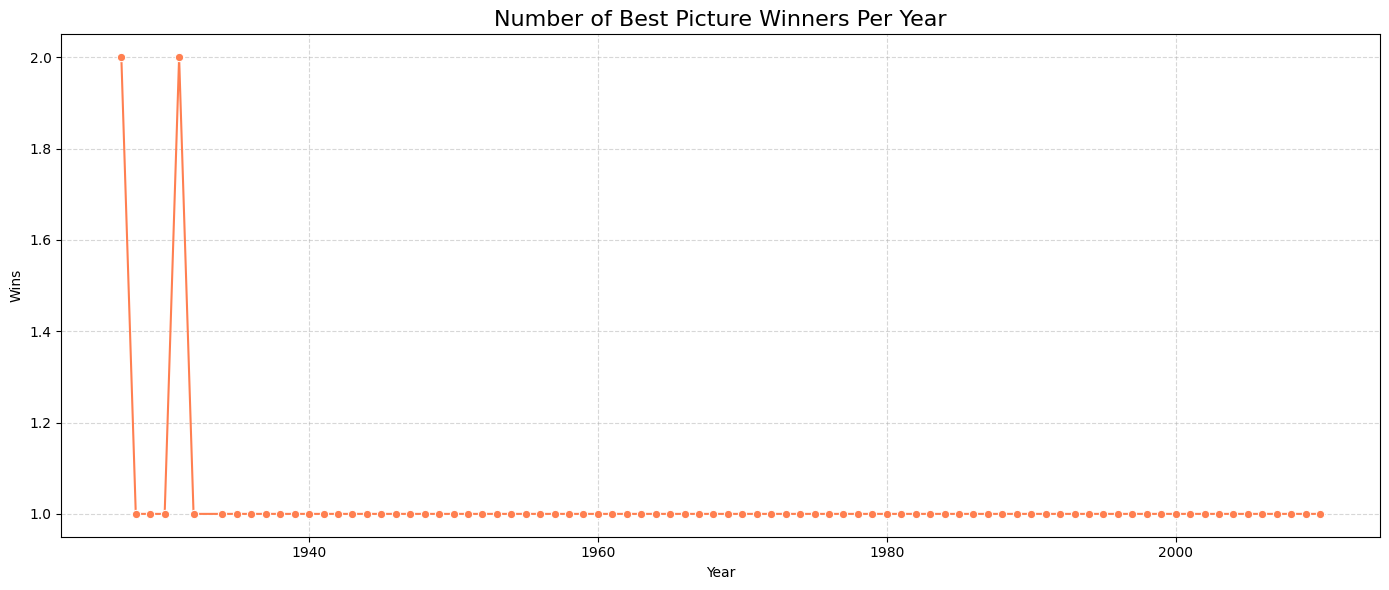

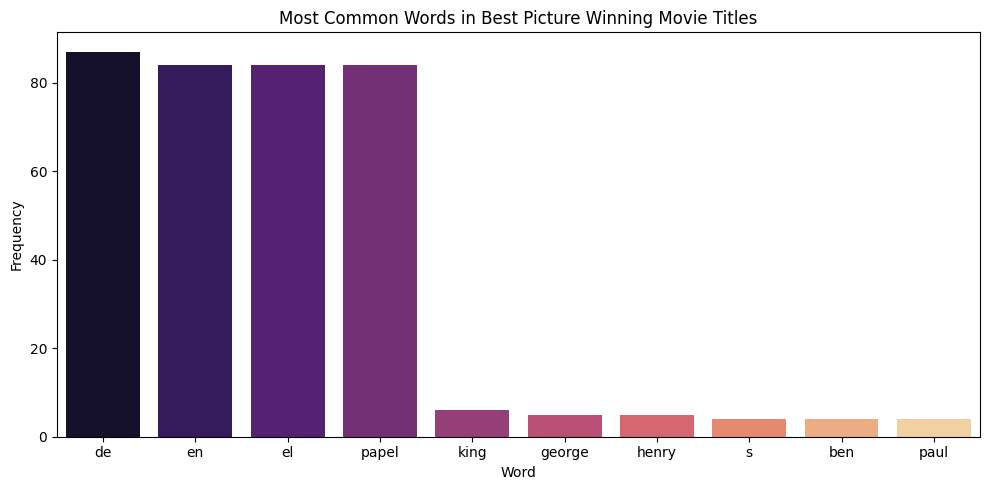

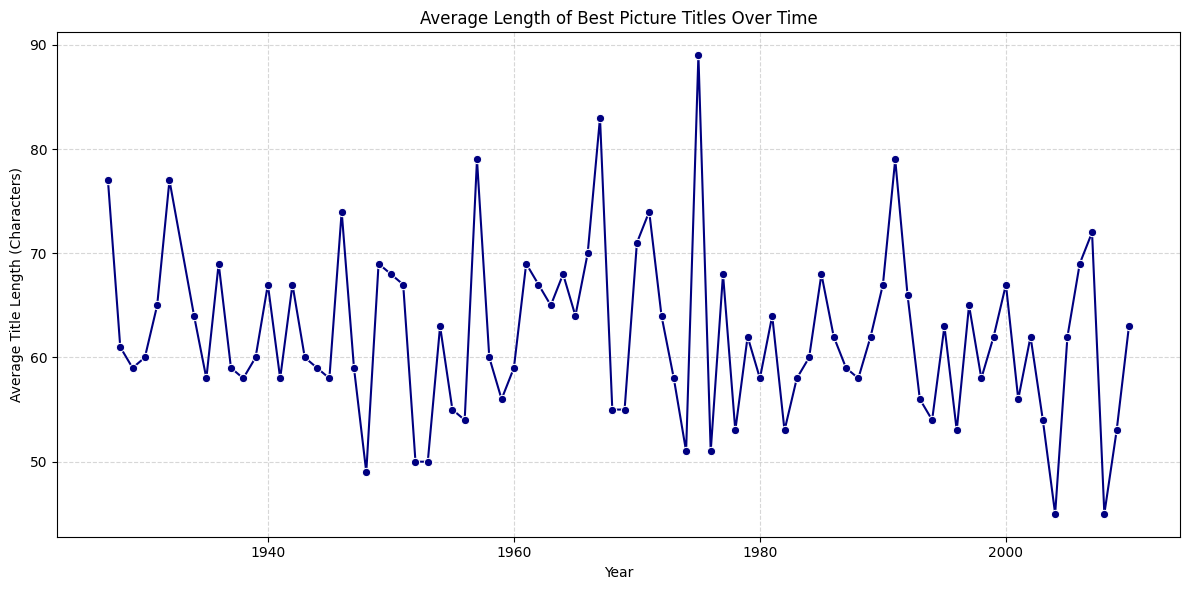

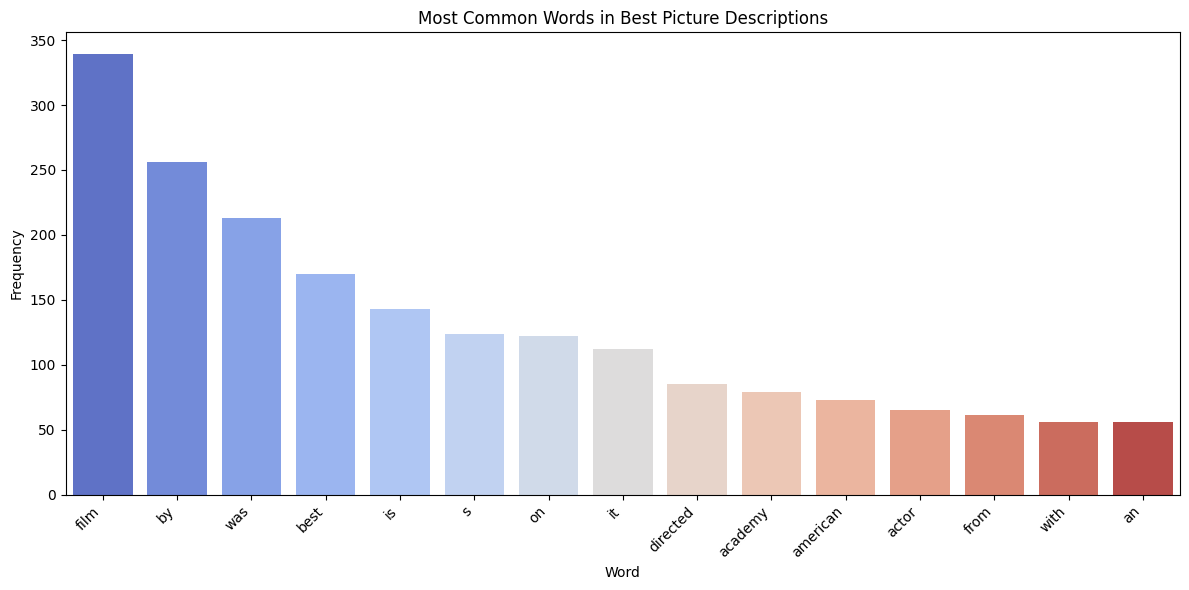

In [11]:
# %% [markdown]
# # 🎬 Oscar Winner Predictor Project
# 
# This notebook explores historical and current Oscar Best Picture winners using data mining and web scraping techniques. We also visualize trends and examine director diversity.

# %% [markdown]
# ## 🗂️ Step 1: Import Libraries

# %%
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests
from bs4 import BeautifulSoup
import re
from collections import Counter
import os
from fuzzywuzzy import process, fuzz
import kagglehub

# %% [markdown]
# ## 🔗 Step 2: Load Historical Data from GitHub

# %%
url_github = "https://raw.githubusercontent.com/fontanon/oscarwinners/master/oscar-winners.csv"

def load_github_data(url):
    df = pd.read_csv(url)
    df = df[['Start', 'Title', 'Description']]
    df.rename(columns={'Start': 'Year', 'Title': 'Movie'}, inplace=True)
    return df

github_data = load_github_data(url_github)

# %% [markdown]
# ## 🌐 Step 3: Scrape Latest Oscar Winners from Wikipedia

# %%
def scrape_latest_winners(url):
    response = requests.get(url)
    soup = BeautifulSoup(response.text, 'html.parser')
    winners = []
    table = soup.find('table', {'class': 'wikitable'})
    rows = table.find_all('tr')[1:]
    for row in rows:
        columns = row.find_all('td')
        if len(columns) >= 2:
            year = columns[0].text.strip()
            movie = columns[1].text.strip()
            winners.append({'Year': year, 'Movie': movie})
    return pd.DataFrame(winners)

latest_data = scrape_latest_winners("https://en.wikipedia.org/wiki/Academy_Award_for_Best_Picture")
latest_data["Description"] = None

# %% [markdown]
# ## 🧼 Step 4: Combine and Clean the Datasets

# %%
combined_data = pd.concat([github_data, latest_data], ignore_index=True)
combined_data.dropna(subset=["Year", "Movie"], inplace=True)
combined_data["Year"] = combined_data["Year"].astype(str).str.extract("([0-9]{4})").dropna().astype(int)
combined_data = combined_data[combined_data["Year"] <= 2025]
combined_data['Movie'] = combined_data['Movie'].str.strip().str.lower()
combined_data['Movie_clean'] = combined_data['Movie'].str.replace(r'[^a-z0-9\s]', '', regex=True)

# %% [markdown]
# ## 📈 Visualization: Number of Best Picture Wins Per Year

# %%
wins_by_year = combined_data.groupby("Year").size().reset_index(name="Count")
plt.figure(figsize=(14, 6))
sns.lineplot(data=wins_by_year, x="Year", y="Count", marker="o", color="coral")
plt.title("Number of Best Picture Winners Per Year", fontsize=16)
plt.xlabel("Year")
plt.ylabel("Wins")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

# %% [markdown]
# ## 📊 Visualization: Most Common Words in Winning Movie Titles

# %%
words = combined_data['Movie'].dropna().apply(lambda x: re.findall(r"\b\w+\b", x.lower()))
flat_words = [word for sublist in words for word in sublist if word not in ['the', 'of', 'and', 'a']]
word_counts = Counter(flat_words).most_common(10)
words_df = pd.DataFrame(word_counts, columns=["Word", "Count"])
plt.figure(figsize=(10, 5))
sns.barplot(data=words_df, x="Word", y="Count", hue="Word", palette="magma", legend=False)
plt.title("Most Common Words in Best Picture Winning Movie Titles")
plt.xlabel("Word")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# %% [markdown]
# ## 🌍 Diversity Analysis: Racial Representation of Best Picture Directors

# %%
try:
    dataset_path = kagglehub.dataset_download("thedevastator/oscar-winning-directors-analysis")
    director_csv = os.path.join(dataset_path, "Oscar Winners - Director.csv")
    directors_df = pd.read_csv(director_csv)

    # Clean and match
    directors_df.rename(columns={'Year of Award': 'Year', 'Film': 'Movie'}, inplace=True)
    directors_df = directors_df[directors_df['Nomination/Winner'] == 'Winner']
    directors_df['Year'] = directors_df['Year'].astype(str).str.extract(r'(\d{4})')
    directors_df.dropna(subset=['Year'], inplace=True)
    directors_df['Year'] = directors_df['Year'].astype(int)
    directors_df['Movie_clean'] = directors_df['Movie'].str.lower().str.replace(r'[^a-z0-9\s]', '', regex=True)

    #titles
    matched_movies = [
        process.extractOne(title, combined_data['Movie_clean'], scorer=fuzz.ratio)[0]
        for title in directors_df['Movie_clean']
    ]
    directors_df['Matched_Movie'] = matched_movies
    merged_df = pd.merge(combined_data, directors_df,
                         left_on=['Year', 'Movie_clean'],
                         right_on=['Year', 'Matched_Movie'], how='left')

    race_counts = merged_df['Race'].dropna().value_counts()


except Exception as e:
    print("⚠️ Could not fetch or process director dataset:", str(e))

# %% [markdown]
# %% [markdown]
# ## 📐 Visualization: Title Length Over Time
# This chart explores how the average length (in characters) of Best Picture titles has changed over the years.

# %%
combined_data["Title_Length"] = combined_data["Movie"].apply(lambda x: len(str(x)))
avg_length_by_year = combined_data.groupby("Year")["Title_Length"].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(data=avg_length_by_year, x="Year", y="Title_Length", marker="o", color="navy")
plt.title("Average Length of Best Picture Titles Over Time")
plt.xlabel("Year")
plt.ylabel("Average Title Length (Characters)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

# %% [markdown]
# ## ✏️ Text Mining: Most Common Words in Descriptions
# This visualization highlights the most frequent words in film descriptions of Oscar Best Picture winners.

# %%
description_words = combined_data['Description'].dropna().apply(lambda x: re.findall(r'\b\w+\b', x.lower()))
filtered_words = [
    word for desc in description_words for word in desc
    if word not in ['the', 'and', 'of', 'in', 'a', 'to', 'his', 'her', 'as', 'for']
]
desc_word_counts = Counter(filtered_words).most_common(15)

desc_words_df = pd.DataFrame(desc_word_counts, columns=["Word", "Count"])

plt.figure(figsize=(12, 6))
sns.barplot(data=desc_words_df, x="Word", y="Count", hue="Word", palette="coolwarm", legend=False)
plt.title("Most Common Words in Best Picture Descriptions")
plt.xlabel("Word")
plt.ylabel("Frequency")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# %% [markdown]
# ## ✅ Final Summary
# - Historical and current Oscar Best Picture data were collected and merged using scraping and open datasets.
# - Visualizations revealed trends in win frequency, title naming conventions, and language patterns.
# 
# ### 🧠 Future Improvements:
# - Incorporate genre, country, or box office info for better modeling.
# - Implement predictive modeling using features like critic score or keyword embeddings.
# - Use clustering to analyze film theme similarities over decades.

# End of notebook.